In [1]:
import fitsio
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("specs5_farfield_style.mplstyle")

LIGHT_SPEED = 299792.458 # km/s
LYA_WAVELENGTH = 1215.67 # Angstroms

# Load DESI DR1 data and covariance matrices. (SNR > 3) sample.
# This can be downloaded from https://zenodo.org/records/16943723
fts = fitsio.FITS(
    "../../../dr1_qmle/"
    "desi_y1_snr3_p1d_sb1subt_qmle_power_estimate_contcorr_v3.fits"
)
print(fts)
hdr = fts[1].read_header()
nk = hdr['NK']
nz = hdr['NZ']
desi_dr1_data = fts[1].read() # .reshape(nz, nk)
desi_dr1_systematics = fts[2].read() # .reshape(nz, nk)
desi_dr1_cov_total = fts['COVARIANCE'].read()
desi_dr1_cov_stat = fts['COVARIANCE_STAT'].read()
desi_dr1_cov_syst = fts['COVARIANCE_SYST'].read()
fts.close()


  file: ../../../dr1_qmle/desi_y1_snr3_p1d_sb1subt_qmle_power_estimate_contcorr_v3.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      P1D_BLIND
  2      BINARY_TBL      SYSTEMATICS
  3      IMAGE_HDU       COVARIANCE
  4      IMAGE_HDU       COVARIANCE_STAT
  5      IMAGE_HDU       COVARIANCE_SYST


In [ ]:
def getSimpleAmplitudeSigma(cov, pin=desi_dr1_data['PSMOOTH'], ddata=desi_dr1_data):
    # apply scale cuts
    desi_dlambda = 0.8  # Angstroms
    desi_rkms = (
        LIGHT_SPEED * desi_dlambda
        / (1 + ddata['Z']) / LYA_WAVELENGTH
    )
    desi_kmax = np.pi / desi_rkms / 2
    w = (ddata['K'] < desi_kmax) & (ddata['K'] > 1e-3)
    # print(f"Using {w.sum()} out of {len(w)} modes")
    pin = pin[w]
    cov = cov[np.ix_(w, w)]
    # print(np.linalg.eigvalsh(cov))
    return np.sqrt(1 / pin.dot(np.linalg.inv(cov)).dot(pin))

In [4]:
# DESI DR1 "amplitude" Fisher forecast
# dP1d / da C^-1 dP1d / da = 1 / sigma_a^2, dP1d / da = Psmooth

sigma_a_dr1 = getSimpleAmplitudeSigma(desi_dr1_cov_total)
sigma_a_dr1


np.float64(0.0013777591564711577)

In [5]:
# We can estimate this statistical covariance using quickquasars
# Here I assume statistical covariance will improve by a factor of 4
# (2x more quasars, 2x more exposure time),
# and systematic covariance will stay the same
desi_dr3_cov_total = desi_dr1_cov_stat / 4 + desi_dr1_cov_syst
sigma_a_dr3 = getSimpleAmplitudeSigma(desi_dr3_cov_total)
sigma_a_dr3

np.float64(0.0009555274734361528)

In [6]:
# Similar to DESI DR3, assume statistical covariance by an order of magnitude,
# and systematic covariance stays the same
specs5_cov_total = desi_dr1_cov_stat / 4 / 10 + desi_dr1_cov_syst
sigma_a_specs5 = getSimpleAmplitudeSigma(specs5_cov_total)
sigma_a_specs5

np.float64(0.0006875910587250108)

In [7]:
print("SpecS5 improvement over DR1:", sigma_a_dr1 / sigma_a_specs5)
print("SpecS5 improvement over DR3:", sigma_a_dr3 / sigma_a_specs5)

SpecS5 improvement over DR1: 2.0037479239853915
SpecS5 improvement over DR3: 1.389674082161528


In [8]:
# Consider improving only high-z forest, where we have fewer quasars and more room for improvement
# Keep the same statistical covariance at low z, but improve by an order of magnitude at high z
improve_only_z = desi_dr1_data['Z'] > 3.5

specs5_cov_total_highz = desi_dr1_cov_stat / 4  # DESI Y5
specs5_cov_total_highz[np.ix_(improve_only_z, improve_only_z)] /= 40
specs5_cov_total_highz += desi_dr1_cov_syst

sigma_a_specs5_highz = getSimpleAmplitudeSigma(specs5_cov_total_highz)
sigma_a_specs5_highz
print("SpecS5 (high-z only) improvement over DR1:", sigma_a_dr1 / sigma_a_specs5_highz)
print("SpecS5 (high-z only) improvement over DR3:", sigma_a_dr3 / sigma_a_specs5_highz)


SpecS5 (high-z only) improvement over DR1: 1.8425653548591887
SpecS5 (high-z only) improvement over DR3: 1.2778879457270702


Assuming systematics do not improve


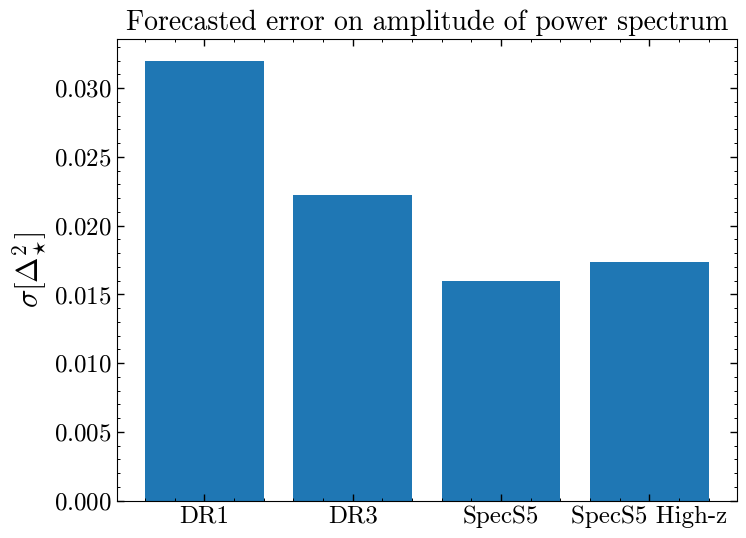

In [9]:
print("Assuming systematics do not improve")
plt.figure(figsize=(8, 6))
dr1_delta2star_std= 0.032
scenarios = ["DR1", "DR3", "SpecS5", "SpecS5 High-z"]
sigmas = np.array([
    sigma_a_dr1, sigma_a_dr3, sigma_a_specs5, sigma_a_specs5_highz
]) * dr1_delta2star_std / sigma_a_dr1
plt.bar(scenarios, sigmas)
plt.ylabel(r"$\sigma[\Delta^2_{\star}]$")
plt.title("Forecasted error on amplitude of power spectrum")
plt.grid(False)
plt.show()

In [10]:
# Try redshift split
cov_to_use = specs5_cov_total
low_sample = desi_dr1_data['Z'] < 3.5
high_sample = desi_dr1_data['Z'] > 3.5
sigma_a_specs5_low = getSimpleAmplitudeSigma(
    cov_to_use[np.ix_(low_sample, low_sample)],
    pin=desi_dr1_data['PSMOOTH'][low_sample],
    ddata=desi_dr1_data[low_sample]
)
sigma_a_specs5_high = getSimpleAmplitudeSigma(
    cov_to_use[np.ix_(high_sample, high_sample)],
    pin=desi_dr1_data['PSMOOTH'][high_sample],
    ddata=desi_dr1_data[high_sample]
)
print("SpecS5 low-z sigma:", sigma_a_specs5_low)
print("SpecS5 high-z sigma:", sigma_a_specs5_high)

SpecS5 low-z sigma: 0.000773991252773324
SpecS5 high-z sigma: 0.0015041230349622354


In [11]:
# Try redshift split
cov_to_use = desi_dr1_cov_total
low_sample = desi_dr1_data['Z'] < 3.5
high_sample = desi_dr1_data['Z'] > 3.5
sigma_a_dr1_low = getSimpleAmplitudeSigma(
    cov_to_use[np.ix_(low_sample, low_sample)],
    pin=desi_dr1_data['PSMOOTH'][low_sample],
    ddata=desi_dr1_data[low_sample]
)
sigma_a_dr1_high = getSimpleAmplitudeSigma(
    cov_to_use[np.ix_(high_sample, high_sample)],
    pin=desi_dr1_data['PSMOOTH'][high_sample],
    ddata=desi_dr1_data[high_sample]
)
print("DR1 low-z sigma:", sigma_a_dr1_low)
print("DR1 high-z sigma:", sigma_a_dr1_high)

DR1 low-z sigma: 0.0014585511650622384
DR1 high-z sigma: 0.004581419895303496


Assuming systematics do not improve


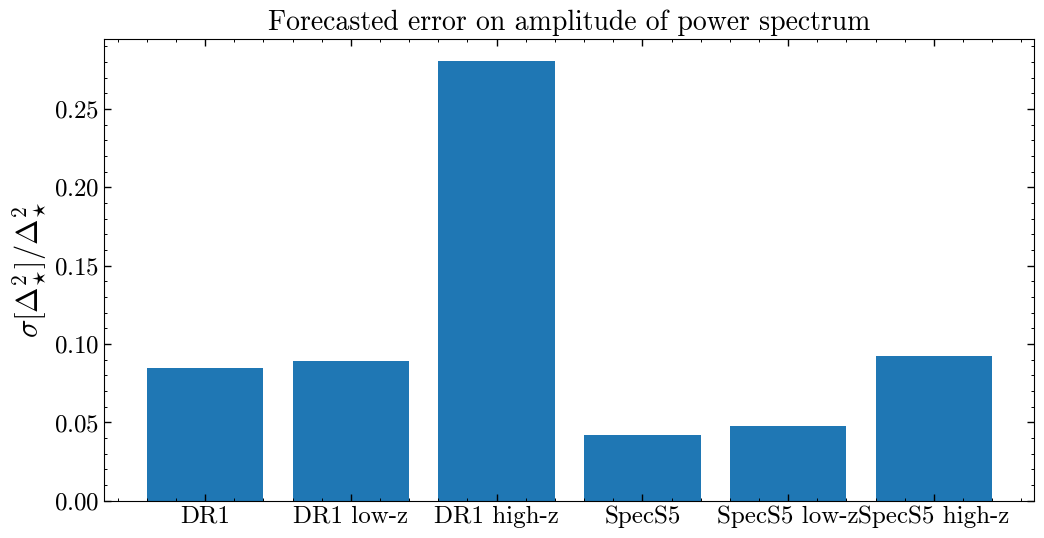

In [12]:
print("Assuming systematics do not improve")
plt.figure(figsize=(12, 6))
dr1_delta2star_std= 0.032
dr1_delta2star_mean= 0.379
scenarios = ["DR1", "DR1 low-z", "DR1 high-z", "SpecS5", "SpecS5 low-z", "SpecS5 high-z"]
sigmas = np.array([
    sigma_a_dr1, sigma_a_dr1_low, sigma_a_dr1_high, sigma_a_specs5, sigma_a_specs5_low, sigma_a_specs5_high
]) * dr1_delta2star_std / sigma_a_dr1 / dr1_delta2star_mean
plt.bar(scenarios, sigmas)
plt.ylabel(r"$\sigma[\Delta^2_{\star}] / \Delta^2_{\star}$")
plt.title("Forecasted error on amplitude of power spectrum")
plt.grid(False)
plt.show()

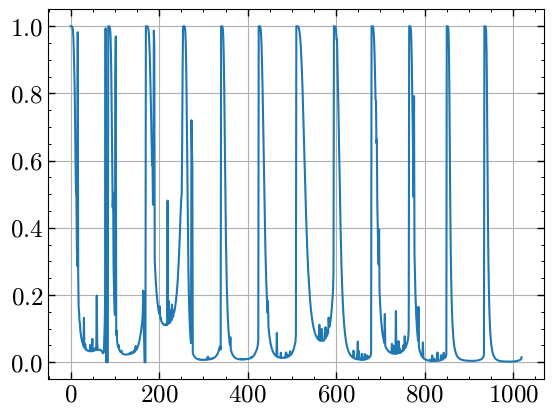

In [13]:
# Eliminate some systematics to see how much improvement we can get
improved_syst_cov = desi_dr1_cov_syst.copy()
ELIMINATE_RESOLUTION = True
ELIMINATE_NOISE = False
ELIMINATE_CONTINUUM = False

# Can also:
# Improve resolution systematics from 1.5% to 1.0%
# Improve noise systematics by 30%
# DLA completeness? BAL completeness? Continuum fitting?
if ELIMINATE_RESOLUTION:
    subcov = np.zeros_like(desi_dr1_cov_syst)
    v = desi_dr1_systematics['E_RESOLUTION'] # * 5 / 15
    for i in range(nz):
        g = v[i * nk:(i + 1) * nk]
        subcov[i * nk:(i + 1) * nk, i * nk:(i + 1) * nk] = np.outer(g, g)

    improved_syst_cov -= subcov

if ELIMINATE_NOISE:
    v = desi_dr1_systematics['E_NOISE_SCALE'] #* 3 / 10
    subcov = np.zeros_like(desi_dr1_cov_syst)
    for i in range(nz):
        g = v[i * nk:(i + 1) * nk]
        subcov[i * nk:(i + 1) * nk, i * nk:(i + 1) * nk] = np.outer(g, g)

    improved_syst_cov -= subcov

if ELIMINATE_CONTINUUM:
    v = desi_dr1_systematics['E_CONTINUUM'] #* 3 / 10
    subcov = np.zeros_like(desi_dr1_cov_syst)
    for i in range(nz):
        g = v[i * nk:(i + 1) * nk]
    subcov[i * nk:(i + 1) * nk, i * nk:(i + 1) * nk] = np.outer(g, g)

    improved_syst_cov -= subcov


plt.plot(improved_syst_cov.diagonal() / desi_dr1_cov_syst.diagonal())

In [14]:
# Similar to DESI DR3, assume statistical covariance by an order of magnitude,
# and systematic covariance improves
# specs5_cov_total = desi_dr1_cov_stat / 4 / 10 + desi_dr1_cov_syst
# sigma_a_specs5 = getSimpleAmplitudeSigma(specs5_cov_total)
# sigma_a_specs5

specs5_cov_total_improved_resolution = desi_dr1_cov_stat / 4 / 10 + improved_syst_cov
sigma_a_specs5_improved_resolution = getSimpleAmplitudeSigma(
    specs5_cov_total_improved_resolution
)
print("Improvement factor from eliminating some systematics (set above):",
      sigma_a_specs5 / sigma_a_specs5_improved_resolution)


Improvement factor from eliminating some systematics (set above): 1.0144338292430828
